
# Integración de Entrenamiento para Detección de Emociones
Este notebook reestructura el proceso de entrenamiento en tres fases:
1. **Entrenamiento con datos de sensores.**
2. **Combinación con datos de texto para un modelo conjunto.**
3. **Extensión del modelo conjunto con imágenes.**
Se corrigen los errores de normalización, división y otros procesos identificados.


In [ ]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Flatten, Input, concatenate
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os


## Fase 1: Entrenamiento con datos de sensores

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Carga de datos de sensores
sensor_data = pd.read_csv("/content/drive/MyDrive/IA_ProyectoAgosto/dataset_2_sensores.csv")  # Cambiar ruta según el archivo real
X_sensors = sensor_data.iloc[:, :-1].values  # Variables de entrada
y_sensors = sensor_data.iloc[:, -1].values  # Etiqueta de salida

# Normalización de datos
scaler = StandardScaler()
X_sensors = scaler.fit_transform(X_sensors)

# Codificación de etiquetas
encoder = LabelEncoder()
y_sensors = encoder.fit_transform(y_sensors)
y_sensors = to_categorical(y_sensors)

# División en entrenamiento y prueba
X_train_sensors, X_test_sensors, y_train_sensors, y_test_sensors = train_test_split(
    X_sensors, y_sensors, test_size=0.2, random_state=42)

# Construcción del modelo para sensores
sensor_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sensors.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(y_sensors.shape[1], activation='softmax')
])

sensor_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento
history_sensors = sensor_model.fit(X_train_sensors, y_train_sensors, validation_split=0.2, epochs=10, batch_size=32)


Mounted at /content/drive
Epoch 1/10
117/117 [==============================] - 1s 4ms/step - loss: 1.0137 - accuracy: 0.6213 - val_loss: 0.7304 - val_accuracy: 0.7169
Epoch 2/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7615 - accuracy: 0.6891 - val_loss: 0.7027 - val_accuracy: 0.7147
Epoch 3/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7508 - accuracy: 0.6902 - val_loss: 0.6904 - val_accuracy: 0.7191
Epoch 4/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7298 - accuracy: 0.7023 - val_loss: 0.6813 - val_accuracy: 0.7255
Epoch 5/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7262 - accuracy: 0.7009 - val_loss: 0.6876 - val_accuracy: 0.7234
Epoch 6/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7170 - accuracy: 0.7096 - val_loss: 0.6661 - val_accuracy: 0.7309
Epoch 7/10
117/117 [==============================] - 0s 2ms/step - loss: 0.7159 - accuracy: 0.7098 - val_loss: 0.6655 - v

## Fase 2: Integración con datos de texto

In [ ]:
# Carga de datos de texto
text_data = pd.read_csv("/content/drive/MyDrive/IA_ProyectoAgosto/dataset_1_texto.csv")  # Cambiar ruta según archivo
X_text = text_data['Text']
y_text = text_data['Etiqueta']

# Handle NaN values in y_text
y_text = y_text.fillna('unknown')  # Replace NaN with 'unknown' or any other placeholder

# Preprocesamiento de texto (tokenización y secuencias)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_text)
X_text_seq = tokenizer.texts_to_sequences(X_text)
X_text_padded = pad_sequences(X_text_seq, maxlen=100)

# Create a new LabelEncoder for text data
encoder_text = LabelEncoder()
y_text = encoder_text.fit_transform(y_text) #Fit on text data
y_text = to_categorical(y_text)


# División en entrenamiento y prueba
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text_padded, y_text, test_size=0.2, random_state=42)

# Construcción del modelo para texto
text_input = Input(shape=(100,))
text_embedding = Embedding(input_dim=5000, output_dim=64)(text_input)
text_lstm = LSTM(64)(text_embedding)
text_output = Dense(y_text.shape[1], activation='softmax')(text_lstm)
text_model = Model(inputs=text_input, outputs=text_output)
text_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento
text_model.fit(X_train_text, y_train_text, validation_split=0.2, epochs=10, batch_size=32)

# Combinación del modelo de sensores y texto
combined_input = concatenate([sensor_model.output, text_model.output])
combined_dense = Dense(64, activation='relu')(combined_input)
combined_output = Dense(y_sensors.shape[1], activation='softmax')(combined_dense)
combined_model = Model(inputs=[sensor_model.input, text_model.input], outputs=combined_output)
combined_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Epoch 1/10
24/24 [==============================] - 3s 64ms/step - loss: 1.6408 - accuracy: 0.3154 - val_loss: 1.4442 - val_accuracy: 0.3226
Epoch 2/10
24/24 [==============================] - 1s 45ms/step - loss: 1.2696 - accuracy: 0.5876 - val_loss: 0.9296 - val_accuracy: 0.8011
Epoch 3/10
24/24 [==============================] - 1s 45ms/step - loss: 0.5979 - accuracy: 0.8504 - val_loss: 0.3874 - val_accuracy: 0.9247
Epoch 4/10
24/24 [==============================] - 1s 45ms/step - loss: 0.2194 - accuracy: 0.9811 - val_loss: 0.1552 - val_accuracy: 0.9785
Epoch 5/10
24/24 [==============================] - 1s 46ms/step - loss: 0.0749 - accuracy: 0.9973 - val_loss: 0.0829 - val_accuracy: 0.9892
Epoch 6/10
24/24 [==============================] - 1s 44ms/step - loss: 0.0281 - accuracy: 1.0000 - val_loss: 0.0594 - val_accuracy: 0.9892
Epoch 7/10
24/24 [==============================] - 1s 45ms/step - loss: 0.0216 - accuracy: 0.9973 - val_loss: 0.0607 - val_accuracy: 0.9892
Epoch 8/10
24

## Fase 3: Integración con imágenes

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Load image features from CSV
image_features_df = pd.read_csv("/content/drive/MyDrive/IA_ProyectoAgosto/image_features.csv")

# Assuming columns 'feature_0' to 'feature_511' are the features
# and 'label' column contains the image labels
X_images = image_features_df.drop('label', axis=1).values
y_images = image_features_df['label'].values

# Convert string labels to numerical using LabelEncoder
label_encoder = LabelEncoder()
y_images = label_encoder.fit_transform(y_images)

# Now apply to_categorical
y_images = to_categorical(y_images)

# Split into train and validation sets
X_train_images, X_val_images, y_train_images, y_val_images = train_test_split(
    X_images, y_images, test_size=0.2, random_state=42
)

# Build the image model
image_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_images.shape[1],)),  # Input shape based on 512 features
    Dense(64, activation='relu'),
    Dense(y_images.shape[1], activation='softmax')  # Output shape based on number of classes
])

image_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the image model
image_model.fit(X_train_images, y_train_images, validation_data=(X_val_images, y_val_images), epochs=10)




# Combinación final
final_combined_input = concatenate([combined_model.output, image_model.output])
final_dense = Dense(64, activation='relu')(final_combined_input)
final_output = Dense(y_sensors.shape[1], activation='softmax')(final_dense)
final_model = Model(inputs=[sensor_model.input, text_model.input, image_model.input], outputs=final_output)
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Epoch 1/10
583/583 [==============================] - 2s 3ms/step - loss: 1.2888 - accuracy: 0.4681 - val_loss: 1.1884 - val_accuracy: 0.5236
Epoch 2/10
583/583 [==============================] - 2s 3ms/step - loss: 1.1728 - accuracy: 0.5224 - val_loss: 1.1662 - val_accuracy: 0.5270
Epoch 3/10
583/583 [==============================] - 2s 3ms/step - loss: 1.1297 - accuracy: 0.5413 - val_loss: 1.1313 - val_accuracy: 0.5401
Epoch 4/10
583/583 [==============================] - 2s 3ms/step - loss: 1.0964 - accuracy: 0.5543 - val_loss: 1.1378 - val_accuracy: 0.5375
Epoch 5/10
583/583 [==============================] - 1s 3ms/step - loss: 1.0727 - accuracy: 0.5692 - val_loss: 1.1004 - val_accuracy: 0.5577
Epoch 6/10
583/583 [==============================] - 1s 2ms/step - loss: 1.0466 - accuracy: 0.5765 - val_loss: 1.1048 - val_accuracy: 0.5545
Epoch 7/10
583/583 [==============================] - 1s 2ms/step - loss: 1.0272 - accuracy: 0.5932 - val_loss: 1.0838 - val_accuracy: 0.5652
Epoch 

## Guardado del modelo final

In [ ]:

final_model.save("/content/drive/MyDrive/IA_ProyectoAgosto/Diciembre/modelo_final.h5")


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Sensor Model Results:
Loss: 0.6723
Accuracy: 0.7227
37/37 [==============================] - 0s 1ms/step
Examples of predicted emotions (first 5):
  Predicted: 3, True: 3
  Predicted: 3, True: 1
  Predicted: 4, True: 4
  Predicted: 4, True: 4
  Predicted: 2, True: 2


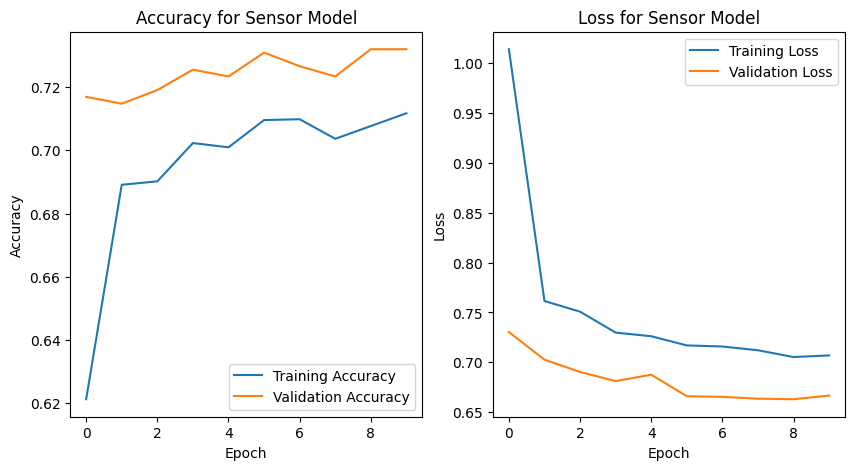


Text Model Results:
Loss: 0.0096
Accuracy: 1.0000
8/8 [==============================] - 0s 12ms/step
Examples of predicted emotions (first 5):
  Predicted: 4, True: 4
  Predicted: 4, True: 4
  Predicted: 1, True: 1
  Predicted: 1, True: 1
  Predicted: 1, True: 1

Combined Model Results:
Loss: 1.6147
Accuracy: 0.2112
8/8 [==============================] - 0s 12ms/step
Examples of predicted emotions (first 5):
  Predicted: 1, True: 3
  Predicted: 1, True: 1
  Predicted: 0, True: 4
  Predicted: 0, True: 4
  Predicted: 0, True: 2

Final Model Results:
Loss: 1.6214
Accuracy: 0.1638
8/8 [==============================] - 0s 13ms/step
Examples of predicted emotions (first 5):
  Predicted: 2, True: 3
  Predicted: 2, True: 1
  Predicted: 2, True: 4
  Predicted: 0, True: 4
  Predicted: 2, True: 2


In [ ]:
# prompt: escribe el código de python siguiendo el contenido de los codigos anteriores, para mostrar las tablas de resultados de cada modelo por separado y luego combinados: accuracy y loss, muestra las emociones encontradas.

import matplotlib.pyplot as plt
import numpy as np


# Train the text model and store history
history_text = text_model.fit(X_train_text, y_train_text, validation_split=0.2, epochs=10, batch_size=32)

# Train the image model and store history
history_image = image_model.fit(X_train_images, y_train_images, validation_data=(X_val_images, y_val_images), epochs=10)







# Evaluate each model and print results
def evaluate_and_print_results(model, X_test, y_test, model_name, history=None):  # Added history parameter

    # Check if X_test is a list (for combined models)
    if isinstance(X_test, list):
        # If it's the combined model, only consider sensor and text data
        if model_name == "Combined Model":
            num_samples = min(X_test[0].shape[0], X_test[1].shape[0])  # Only sensor and text
            X_test = [X_test[0][:num_samples], X_test[1][:num_samples]]  # Slice for sensor and text
        else:  # For final model (with image data)
            num_samples = min(X_test[0].shape[0], X_test[1].shape[0], X_test[2].shape[0])
            X_test = [X_test[0][:num_samples], X_test[1][:num_samples], X_test[2][:num_samples]]
        y_test = y_test[:num_samples]  # Adjust y_test accordingly


    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{model_name} Results:")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    # Get predicted emotions
    y_pred = model.predict(X_test)
    predicted_emotions = np.argmax(y_pred, axis=1)
    true_emotions = np.argmax(y_test, axis=1)

    # Print some predicted emotions
    print("Examples of predicted emotions (first 5):")
    for i in range(min(5, len(predicted_emotions))): #avoid index error
        print(f"  Predicted: {predicted_emotions[i]}, True: {true_emotions[i]}")

    # Plot accuracy and loss (only for sensor model as it has history_sensors)
    if model_name == "Sensor Model":
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_sensors.history['accuracy'], label='Training Accuracy')
        plt.plot(history_sensors.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'Accuracy for {model_name}')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history_sensors.history['loss'], label='Training Loss')
        plt.plot(history_sensors.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Loss for {model_name}')
        plt.legend()
        plt.show()

# Assuming X_test_sensors, y_test_sensors, etc., are defined in your code
evaluate_and_print_results(sensor_model, X_test_sensors, y_test_sensors, "Sensor Model")
evaluate_and_print_results(text_model, X_test_text, y_test_text, "Text Model")

# Evaluate combined model
combined_input_data = [X_test_sensors, X_test_text]
evaluate_and_print_results(combined_model, combined_input_data, y_test_sensors, "Combined Model")

# Evaluate final model
final_input_data = [X_test_sensors, X_test_text, X_val_images]
evaluate_and_print_results(final_model, final_input_data, y_test_sensors, "Final Model")

In [ ]:
# prompt: Para graficar para texto e imagenes bajo el mismo modelo de sensores:
#     # Plot accuracy and loss (only for sensor model as it has history_sensors)
#     if model_name == "Sensor Model":
#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.plot(history_sensors.history['accuracy'], label='Training Accuracy')
#         plt.plot(history_sensors.history['val_accuracy'], label='Validation Accuracy')
#         plt.xlabel('Epoch')
#         plt.ylabel('Accuracy')
#         plt.title(f'Accuracy for {model_name}')
#         plt.legend()
#         plt.subplot(1, 2, 2)
#         plt.plot(history_sensors.history['loss'], label='Training Loss')
#         plt.plot(history_sensors.history['val_loss'], label='Validation Loss')
#         plt.xlabel('Epoch')
#         plt.ylabel('Loss')
#         plt.title(f'Loss for {model_name}')
#         plt.legend()
#         plt.show()

    # Plot accuracy and loss for text and image models
    if model_name == "Text Model":
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_text.history['accuracy'], label='Training Accuracy')
        plt.plot(history_text.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'Accuracy for {model_name}')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history_text.history['loss'], label='Training Loss')
        plt.plot(history_text.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Loss for {model_name}')
        plt.legend()
        plt.show()
    elif model_name == "Image Model":
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_image.history['accuracy'], label='Training Accuracy')
        plt.plot(history_image.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'Accuracy for {model_name}')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history_image.history['loss'], label='Training Loss')
        plt.plot(history_image.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Loss for {model_name}')
        plt.legend()
        plt.show()